# Data Collection & Initial Inspection
### Wind Turbine Physical Evolution: Bigger, Taller, More Powerful?

This is the first notebook in our project. The goal here is just to load all the datasets, take a first look at them, and make sure everything loaded correctly before I start doing any actual analysis.

I'm not cleaning anything yet, that's for the next notebook. Here I just want to understand what I'm working with.


## 1. Import Libraries

In [2]:
# standard stuff we'll need throughout the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# just setting this so plots look a bit nicer
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("libraries loaded!")


libraries loaded!


## 2. Load the Datasets

I have 5 CSV files and 1 Excel file. The main one I'll be using is `wind-turbines.csv`.
The others give context (electricity rates, wind speeds by state, operator generation data).

**Note:** some of these files have encoding issues with plain utf-8 so I'm using `latin1`. 
I figured this out after getting a weird UnicodeDecodeError the first time I tried to load them.


In [4]:
# defining the folder path so I don't have to type it every time
DATA_PATH = "../data/original/"

# loading all 5 datasets
df_turbines  = pd.read_csv(DATA_PATH + "wind-turbines.csv", encoding="latin1")
df_operators = pd.read_csv(DATA_PATH + "wind-operators.csv", encoding="latin1")
df_bills     = pd.read_csv(DATA_PATH + "average_electricity_bills.csv", encoding="latin1")
df_rates     = pd.read_csv(DATA_PATH + "average_electricity_rates.csv", encoding="latin1")
df_wind      = pd.read_csv(DATA_PATH + "windiest-states-in-the-us.-2025.csv", encoding="latin1")

print("all datasets loaded successfully!")


all datasets loaded successfully!


## 3. Quick Overview of Each Dataset

In [5]:
# I'll just loop through all of them and print the shape + column names
# easier than doing it one by one

datasets = {
    "wind-turbines"   : df_turbines,
    "wind-operators"  : df_operators,
    "elec-bills"      : df_bills,
    "elec-rates"      : df_rates,
    "wind-speed"      : df_wind,
}

for name, df in datasets.items():
    print(f"--- {name} ---")
    print(f"  rows: {df.shape[0]}, columns: {df.shape[1]}")
    print(f"  columns: {list(df.columns)}")
    print()


--- wind-turbines ---
  rows: 70808, columns: 27
  columns: ['case_id', 'faa_ors', 'faa_asn', 'usgs_pr_id', 'eia_id', 't_state', 't_county', 't_fips', 'p_name', 'p_year', 'p_tnum', 'p_cap', 't_manu', 't_model', 't_cap', 't_hh', 't_rd', 't_rsa', 't_ttlh', 'retrofit', 'retrofit_year', 't_conf_atr', 't_conf_loc', 't_img_date', 't_img_srce', 'xlong', 'ylat']

--- wind-operators ---
  rows: 14405, columns: 97
  columns: ['Plant Id', 'Combined Heat And Power Plant', 'Nuclear Unit Id', 'Plant Name', 'Operator Name', 'Operator Id', 'Plant State', 'Census Region', 'NERC Region', 'Reserved', 'NAICS Code', 'EIA Sector Number', 'Sector Name', 'Reported Prime Mover', 'Reported Fuel Type Code', 'AER/MER Fuel Type Code', 'Balancing Authority Code', 'Respondent Frequency', 'Physical Unit Label', 'Quantity January', 'Quantity February', 'Quantity March', 'Quantity April', 'Quantity May', 'Quantity June', 'Quantity July', 'Quantity August', 'Quantity September', 'Quantity October', 'Quantity November', 

## 4. First Look at the Main Dataset (wind-turbines)

In [6]:
# this is my primary dataset so I want to look at it more carefully
df_turbines.head()


,case_id,faa_ors,faa_asn,usgs_pr_id,eia_id,t_state,t_county,t_fips,p_name,p_year,...,t_rsa,t_ttlh,retrofit,retrofit_year,t_conf_atr,t_conf_loc,t_img_date,t_img_srce,xlong,ylat
0,3072661,NaN,NaN,5149.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.363762,35.077908
1,3072695,NaN,NaN,5143.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.364410,35.077435
2,3072704,NaN,NaN,5146.0,52161.0,CA,Kern County,6029,251 Wind,1987.0,...,NaN,NaN,0,NaN,2,3,5/8/2018,Digital Globe,-118.364197,35.077644
3,3063272,19-028134,2014-WTE-4084-OE,NaN,NaN,IA,Story County,19169,30 MW Iowa DG Portfolio,2017.0,...,12271.85,150.0,0,NaN,3,3,4/24/2017,Digital Globe,-93.430367,42.028233
4,3053390,19-028015,2015-WTE-6386-OE,NaN,NaN,IA,Boone County,19015,30 MW Iowa DG Portfolio,2017.0,...,12271.85,150.0,0,NaN,3,3,6/1/2017,Digital Globe,-93.700424,41.977608


In [7]:
# checking the data types for each column
# this helps me know what I need to fix in the cleaning step
df_turbines.dtypes


case_id            int64
faa_ors              str
faa_asn              str
usgs_pr_id       float64
eia_id           float64
t_state              str
t_county             str
t_fips             int64
p_name               str
p_year           float64
p_tnum             int64
p_cap            float64
t_manu               str
t_model              str
t_cap            float64
t_hh             float64
t_rd             float64
t_rsa            float64
t_ttlh           float64
retrofit           int64
retrofit_year    float64
t_conf_atr         int64
t_conf_loc         int64
t_img_date           str
t_img_srce           str
xlong            float64
ylat             float64
dtype: object

In [8]:
# how many nulls are in each column?
# I'll visualize this as a percentage because raw counts are harder to read

null_pct = (df_turbines.isnull().sum() / len(df_turbines) * 100).sort_values(ascending=False)

print("Columns with missing values (%):")
print(null_pct[null_pct > 0].round(2))


Columns with missing values (%):
retrofit_year    91.55
usgs_pr_id       45.96
t_img_date       11.74
t_hh              8.73
t_ttlh            8.73
t_rd              8.38
t_rsa             8.38
eia_id            8.18
faa_ors           8.18
t_model           8.16
t_manu            7.97
t_cap             7.74
faa_asn           7.23
p_cap             6.33
p_year            0.87
dtype: float64


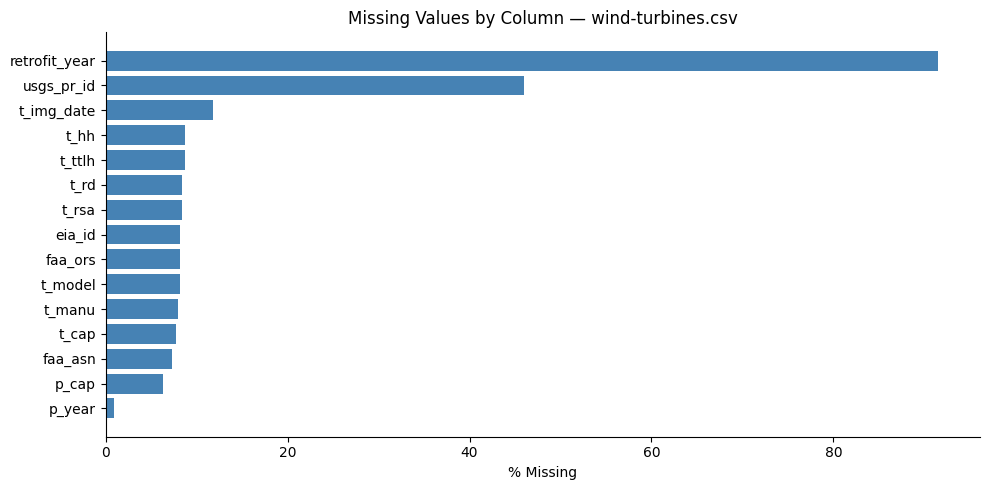

In [9]:
# let me also visualize the nulls so it's easier to see at a glance

null_pct_filtered = null_pct[null_pct > 0]

plt.figure(figsize=(10, 5))
plt.barh(null_pct_filtered.index, null_pct_filtered.values, color='steelblue')
plt.xlabel("% Missing")
plt.title("Missing Values by Column — wind-turbines.csv")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 5. First Look at the Supporting Datasets

In [11]:
# quick peek at each supporting dataset
print("=== electricity rates ===")
print(df_rates.head(3))
print()

print("=== electricity bills ===")
print(df_bills.head(3))
print()

print("=== wind speed by state ===")
print(df_wind.head(3))


=== electricity rates ===
     State  Residential  Commercial  Average
0  Alabama        14.91       13.83    14.37
1   Alaska        22.38       18.43    20.41
2  Arizona        15.20       11.92    13.56

=== electricity bills ===
     State  Residential Commercial Average
0  Alabama       115.00     679.26  397.13
1   Alaska       198.10   1,201.93  700.02
2  Arizona       118.76     645.96  382.36

=== wind speed by state ===
   stateFlagCode         state  WindiestStatesAverageWindSpeedMPH  \
0            NaN  South Dakota                              21.32   
1            NaN       Montana                              21.03   
2            NaN       Wyoming                              20.88   

   MeanWindSpeed328ft  MeanWindPower328ft  MeanWindSpeed33ft  
0                20.3                 722               12.8  
1                20.5                 985               13.5  
2                21.5                 964               14.1  


In [12]:
# checking nulls in supporting datasets too
for name, df in {"elec-rates": df_rates, "elec-bills": df_bills, "wind-speed": df_wind}.items():
    nulls = df.isnull().sum().sum()
    print(f"{name}: {nulls} total missing values")


elec-rates: 0 total missing values
elec-bills: 0 total missing values
wind-speed: 50 total missing values


## 6. Key Columns for This Analysis

In [13]:
# these are the columns I'll be focusing on most based on my problem statement
# just printing a preview so I can confirm they look reasonable

key_cols = ['p_year', 't_cap', 't_hh', 't_rd', 't_rsa', 't_manu', 't_state']

print("Preview of key analysis columns:")
df_turbines[key_cols].head(10)


Preview of key analysis columns:


,p_year,t_cap,t_hh,t_rd,t_rsa,t_manu,t_state
0,1987.0,95.0,NaN,NaN,NaN,Vestas,CA
1,1987.0,95.0,NaN,NaN,NaN,Vestas,CA
2,1987.0,95.0,NaN,NaN,NaN,Vestas,CA
3,2017.0,3000.0,87.5,125.0,12271.85,Nordex,IA
4,2017.0,3000.0,87.5,125.0,12271.85,Nordex,IA
5,2017.0,3000.0,87.5,125.0,12271.85,Nordex,IA
6,2017.0,3000.0,87.5,125.0,12271.85,Nordex,IA
7,2017.0,3000.0,87.5,125.0,12271.85,Nordex,IA
8,2017.0,3000.0,87.5,125.0,12271.85,Nordex,IA
9,2017.0,3000.0,87.5,125.0,12271.85,Nordex,IA


In [14]:
# basic descriptive stats for the numeric key columns
# this gives me a sense of the range and whether there are obvious outliers

df_turbines[['t_cap', 't_hh', 't_rd', 't_rsa', 'p_year']].describe().round(2)


,t_cap,t_hh,t_rd,t_rsa,p_year
count,65328.00,64628.00,64874.00,64874.00,70195.00
mean,1963.53,81.05,95.66,7618.50,2011.65
std,717.07,12.03,23.42,3309.23,7.88
min,50.00,19.00,13.40,141.03,1981.00
25%,1500.00,80.00,82.00,5281.02,2008.00
50%,2000.00,80.00,100.00,7853.98,2012.00
75%,2300.00,87.00,110.00,9503.32,2018.00
max,6000.00,131.00,155.00,18869.19,2021.00


## 8. How Many Unique Values?

In [17]:
# checking cardinality for the categorical columns
print(f"Unique manufacturers (t_manu): {df_turbines['t_manu'].nunique()}")
print(f"Unique states (t_state):       {df_turbines['t_state'].nunique()}")
print(f"Unique projects (p_name):      {df_turbines['p_name'].nunique()}")
print(f"Unique models (t_model):       {df_turbines['t_model'].nunique()}")
print()

# top 10 manufacturers by turbine count
print("Top 10 manufacturers:")
print(df_turbines['t_manu'].value_counts().head(10))


Unique manufacturers (t_manu): 63
Unique states (t_state):       46
Unique projects (p_name):      1708
Unique models (t_model):       315

Top 10 manufacturers:
t_manu
GE Wind                            29137
Vestas                             16259
Siemens                             5035
Gamesa                              3077
Mitsubishi                          2620
Siemens Gamesa Renewable Energy     2043
Nordex                              1591
Suzlon                              1316
Acciona                              758
REpower                              574
Name: count, dtype: int64
